In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/Dengue2.csv')
df1=df['effected-people-per-day']
n=len(df1)
df1=df1.reset_index(drop=True)
df1=np.abs(df1.ffill())
print(df1)

0         4.0
1        11.0
2        29.0
3         4.0
4         4.0
        ...  
1091     53.0
1092    104.0
1093    148.0
1094    114.0
1095     84.0
Name: effected-people-per-day, Length: 1096, dtype: float64


In [3]:
#ind_rang = [(0,58),(59,119),(120,180),(181,242),(243,303),(304,364),(365,423),(424,484),(485,545),(546,607),(608,668),(669,729),(730,789),(790,850),(851,911),(912,973),(974,1034),(1035,1095)]
ind_rang=[(0,89),(90,180),(181,272),(273,364),(365,454),(455,545),(546,637),(638,729),(730,820),(821,911),(912,1003),(1004,1095)]


window = {}

for i, (start, end) in enumerate(ind_rang, start=1):
    window[i]= df1[start:end+1]

In [ ]:
#ind1= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364)]
#ind2 = [(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729)]
#ind3  = [(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]
#window={}

#for i, (start, end) in enumerate(ind2, start=1):
   # window[i]=df1[start:end+1]

0.39102047991510525
0.343798877238759
[0.3853723344123194, 0.3748490436758051, 0.343798877238759, 0.3672156637001553, 0.37230356624189637, 0.39102047991510525, 0.3684032905500296, 0.3670195150291331, 0.3759836796422963, 0.38076577435991243, 0.37267481978495554, 0.36204350345217223]
The average clustering coeffiecient is: 0.37178754566687827


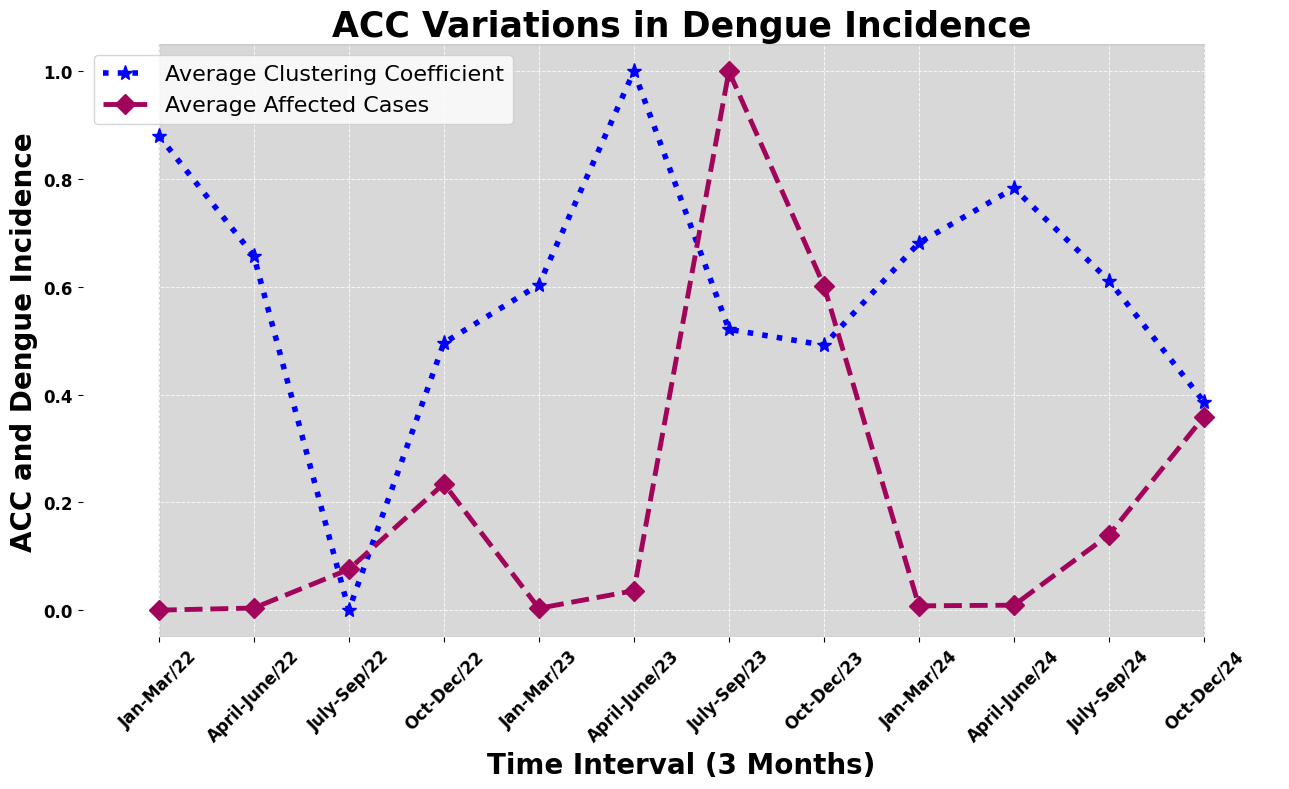

In [24]:
avc = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  G= nx.visibility_graph(data)
  N= G.number_of_nodes()
  c_list =[]

  for node in G.nodes():
    neighbors = list(G.neighbors(node))
    n=len(neighbors)
    # Check if n*(n-1) is zero to prevent division by zero
    if n > 1:
        subgraph = G.subgraph(neighbors)
        m=subgraph.number_of_edges()
        c=m/(n*(n-1))
    else:
        c=0
    c_list.append(c)

  if N > 0:
      acc =sum(c_list)/N
  else:
      acc = 0
  avc.append(acc)
  #avc.append(nx.average_clustering(G))
  average_value1.append(data.mean())

print(max(avc))
print(min(avc))
scaler= MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc).reshape(-1,1))
print(avc)
print("The average clustering coeffiecient is:", sum(avc)/len(avc))

fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Average Clustering Coefficient")

ax.plot(range(len(window)), scaled_value1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('ACC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('ACC Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

3.8994266602962253
2.258119658119658
[2.5091136079900123, 2.6185592185592186, 2.6607740086000957, 3.7047300525561395, 2.865168539325843, 2.258119658119658, 3.7955088389870997, 3.1218346870520786, 2.790964590964591, 3.320634920634921, 2.800286669851887, 3.8994266602962253]
The average shortest path length is: 3.028760121078147


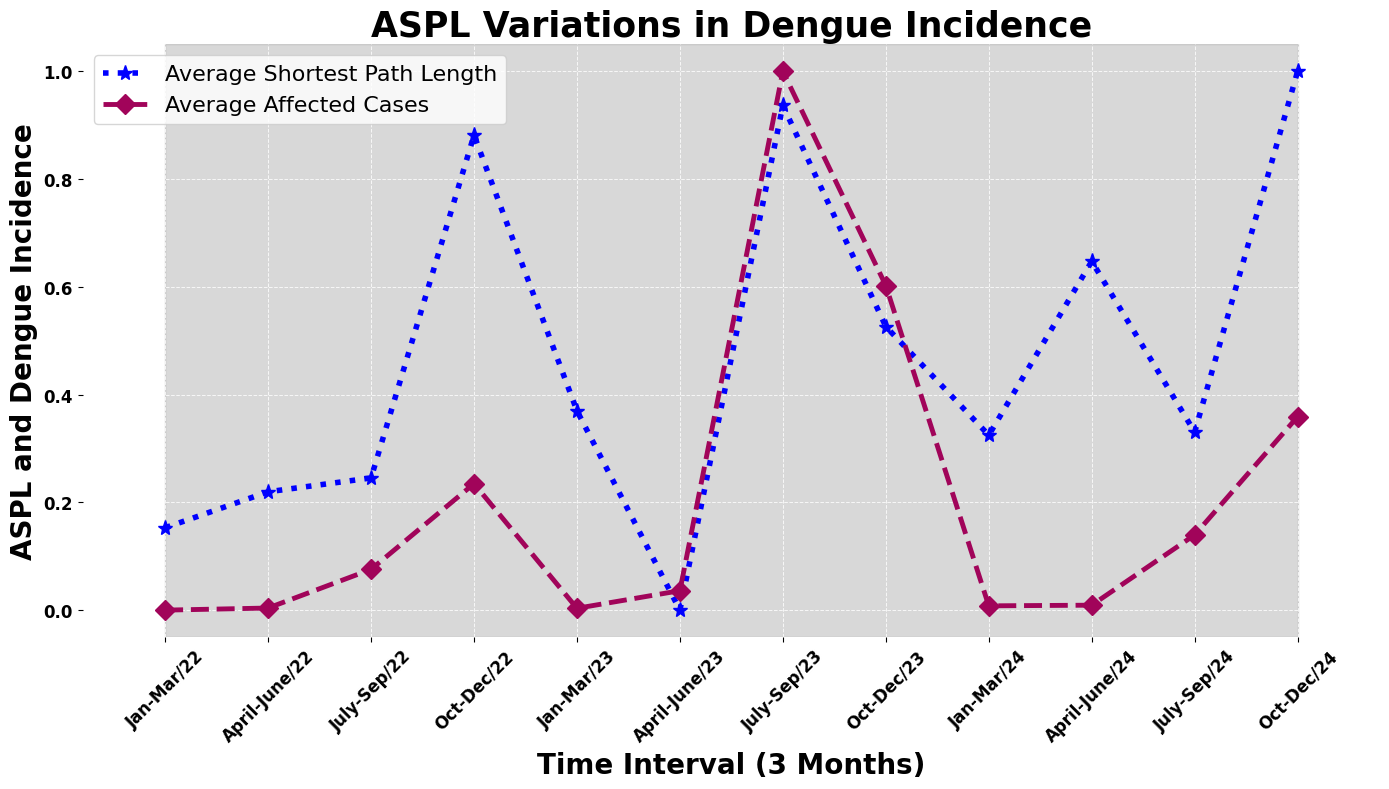

In [25]:
avc = []
average_value1 = []

for i in window:
    data = window[i]

    # Create visibility graph
    G = nx.visibility_graph(data)

    N = G.number_of_nodes()
    total_distance = 0
    count = 0

    # Get shortest path lengths between all pairs
    all_paths = dict(nx.all_pairs_shortest_path_length(G))

    for u in all_paths:
        for v in all_paths[u]:
            if u != v:
                total_distance += all_paths[u][v]
                count += 1

    # Apply formula
    if N > 1:
        L_avg = total_distance / (N * (N - 1))
    else:
        L_avg = 0

    avc.append(L_avg)
    #avc.append(nx.average_shortest_path_length(G))
    average_value1.append(data.mean())

# Scaling
scaler = MinMaxScaler()

scaled_value1 = scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1  = scaler.fit_transform(np.array(avc).reshape(-1,1))
print(max(avc))
print(min(avc))
print(avc)
print("The average shortest path length is:", sum(avc)/len(avc))
# Plot
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Average Shortest Path Length")

ax.plot(range(len(window)), scaled_value1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('ASPL and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('ASPL Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

#plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

0.39035802469135783
0.18107198923525467
[0.30347599208854104, 0.24058230452674903, 0.23468180171476882, 0.19653768523470255, 0.2653242435719395, 0.39035802469135783, 0.18107198923525467, 0.22623504177664336, 0.21301234567901248, 0.22994650205761336, 0.24683009298393935, 0.18667364381650112]
The Global reaching centrality is: 0.2428941389480853


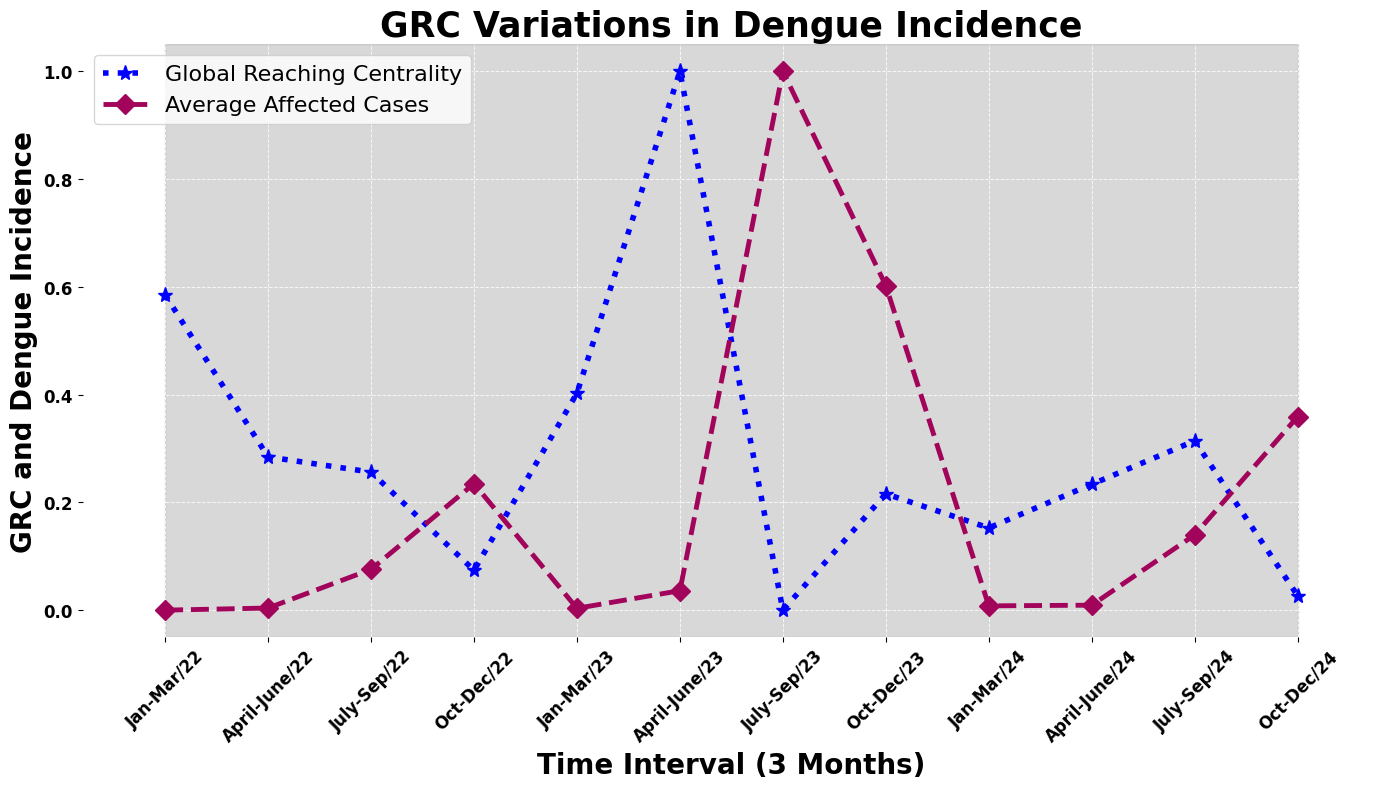

In [26]:
def reaching_centrality(data):

    G = nx.visibility_graph(data)
    N = G.number_of_nodes()

    if N <= 1:
        return 0

    local_CR = []

    # Compute shortest path lengths for all nodes
    all_shortest_paths = dict(nx.all_pairs_shortest_path_length(G))

    for i in G.nodes():

        sum_inverse_distance = 0

        for j in G.nodes():
            if i != j:

                # get distance d(i,j)
                d = all_shortest_paths[i].get(j, 0)

                # avoid division by zero / unreachable nodes
                if d > 0:
                    sum_inverse_distance += 1 / d

        CR_i = sum_inverse_distance / (N - 1)
        local_CR.append(CR_i)

    # ----- Global Reaching Centrality -----

    CR_max = max(local_CR)

    GRC = sum(CR_max - cr for cr in local_CR) / (N - 1)

    return GRC



grc1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  #grc = nx.global_reaching_centrality(G)
  grc = reaching_centrality(data)
  grc1.append(grc)
  avg1.append(data.mean())

sgrc1 = scaler.fit_transform(np.array(grc1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

print(max(grc1))
print(min(grc1))
print(grc1)
print("The Global reaching centrality is:", sum(grc1)/len(grc1))
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), sgrc1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Global Reaching Centrality")

ax.plot(range(len(window)), savg1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('GRC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('GRC Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

0.12283272283272283
0.05733397037744864
[0.07965043695380775, 0.08522588522588523, 0.09173435260391782, 0.06497849976110846, 0.06541822721598002, 0.12283272283272283, 0.06282847587195413, 0.09006211180124224, 0.08180708180708181, 0.061782661782661785, 0.07238413760152891, 0.05733397037744864]
The density is: 0.07800321365294498


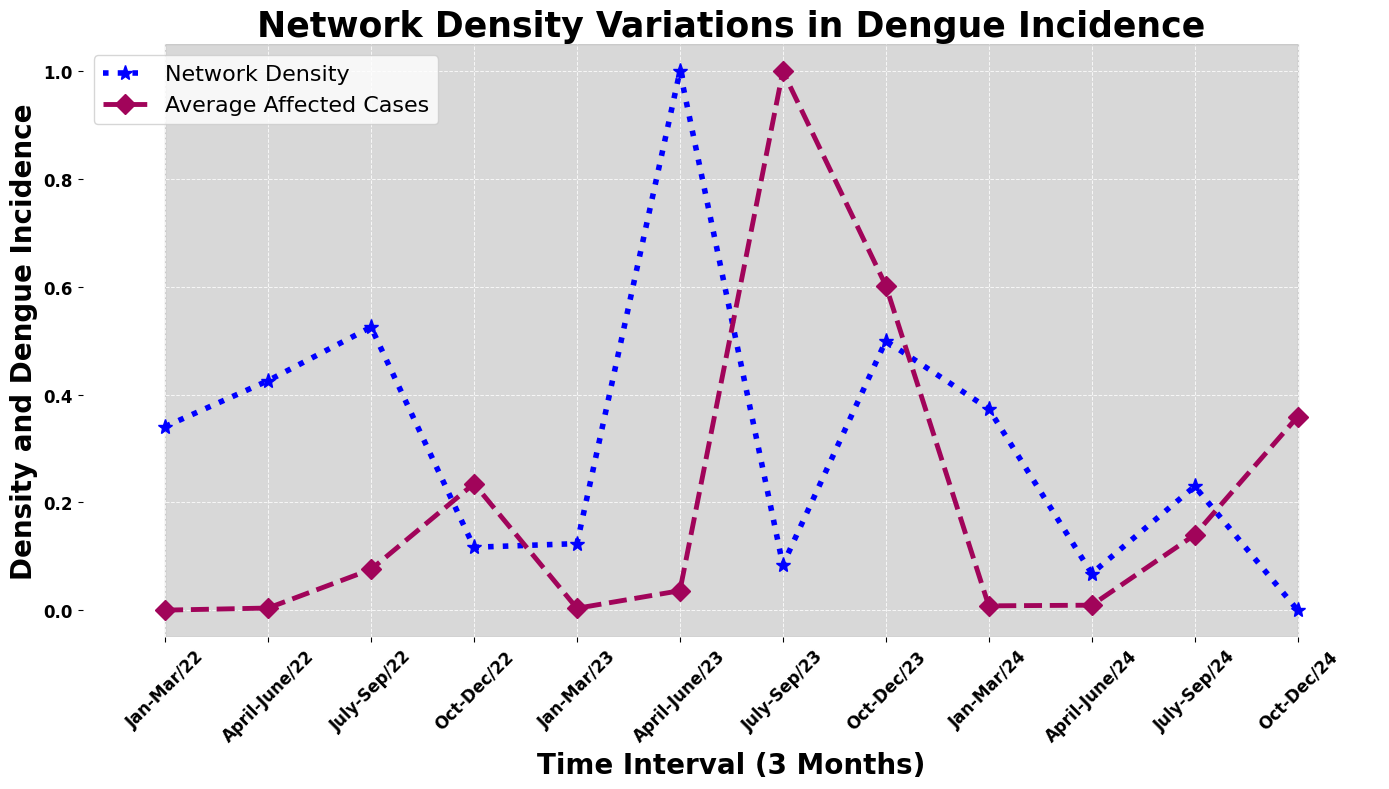

In [27]:


dens1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  #dens = nx.density(G)
  N= G.number_of_nodes()
  m= G.number_of_edges()
  dens=(2*m)/(N*(N-1))
  dens1.append(dens)
  avg1.append(data.mean())

sdens1 = scaler.fit_transform(np.array(dens1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

print(max(dens1))
print(min(dens1))
print(dens1)
print("The density is:", sum(dens1)/len(dens1))
#plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), sdens1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Network Density")

ax.plot(range(len(window)), savg1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('Density and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('Network Density Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

91
0      4.0
1     11.0
2     29.0
3      4.0
4      4.0
      ... 
86     0.0
87     2.0
88     4.0
89     0.0
90     0.0
Name: effected-people-per-day, Length: 91, dtype: float64
start of year: 0 (0, 91)
91      0.0
92      2.0
93      0.0
94      0.0
95      0.0
       ... 
177    17.0
178    47.0
179    40.0
180    33.0
181    22.0
Name: effected-people-per-day, Length: 91, dtype: float64
start of year: 1 (91, 182)
182     49.0
183     42.0
184     36.0
185     46.0
186     32.0
       ...  
268    482.0
269    460.0
270    524.0
271    506.0
272    240.0
Name: effected-people-per-day, Length: 91, dtype: float64
start of year: 2 (182, 273)
273    635.0
274    568.0
275    525.0
276    482.0
277    344.0
       ...  
359    106.0
360     62.0
361     67.0
362     65.0
363     14.0
Name: effected-people-per-day, Length: 91, dtype: float64
start of year: 3 (273, 364)
364    47.0
365    41.0
366    38.0
367    17.0
368    49.0
       ... 
450     4.0
451     6.0
452     2.0
453     6.

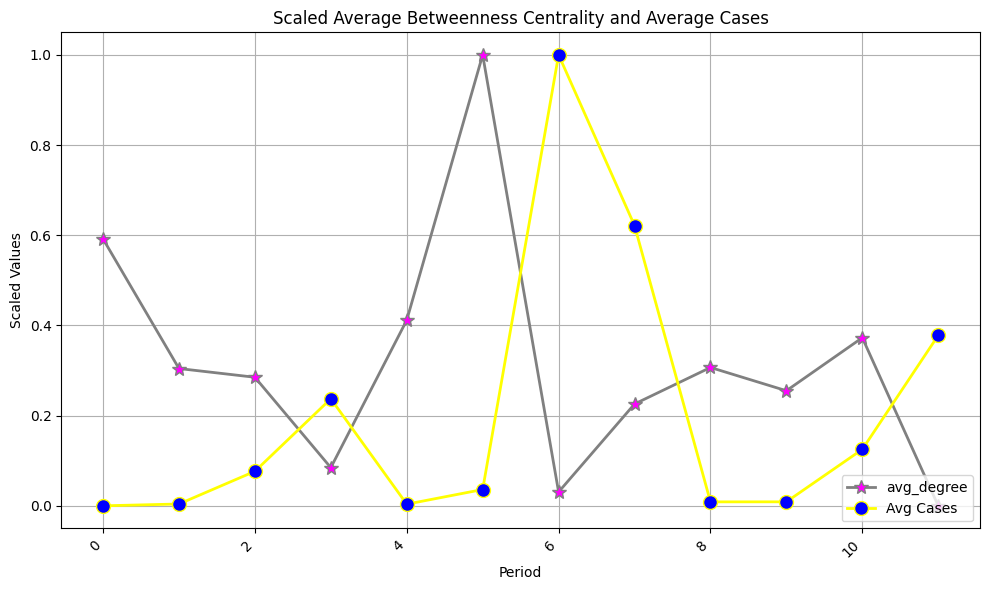

In [ ]:
idx = 0
dur = len(df1)//12
print(dur)
avgpths = []
avgcls = []
edgeden = []
grc = []
avg = []
mod =[]
ass =[]
cen=[]
for yr in range(0, 12):
    data_seg = df1.iloc[idx:idx+dur].copy()
    print(data_seg)
    avg.append(data_seg.mean())
    print('start of year:', yr, (idx, idx+dur))
    G = nx.visibility_graph(data_seg)
    avgpths.append(nx.average_shortest_path_length(G))
    avgcls.append(nx.average_clustering(G))
    edgeden.append(nx.density(G))
    grc.append(nx.global_reaching_centrality(G))
    cen.append(nx.betweenness_centrality(G).values()) # Extract values from the dictionary
    ass.append(nx.degree_assortativity_coefficient(G))
    c =  nx.community.greedy_modularity_communities(G)
    mod.append(nx.community.modularity(G,c ))
    idx += dur

scaler = MinMaxScaler()
avgn = scaler.fit_transform(np.array(avg).reshape(-1, 1))
# Scale the average of the betweenness centrality values
#avg_cen_values = [np.mean(list(c)) for c in cen]
avgpthsn = scaler.fit_transform(np.array(grc).reshape(-1, 1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(window)), avgn, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases") # Changed range to len(window)

plt.xlabel('Period')
plt.ylabel('Scaled Values')
plt.title('Scaled Average Betweenness Centrality and Average Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'lower right')
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
df1

,effected-people-per-day
0,4.0
1,11.0
2,29.0
3,4.0
4,4.0
5,9.0
6,1.0
7,2.0
8,7.0
9,3.0


Z-scores: [np.float64(-1.088036454104299), np.float64(-4.027834384420342), np.float64(-3.505892599170738), np.float64(1.381705616855339), np.float64(-1.1934710050282116), np.float64(-4.913501138972877), np.float64(0.3334647470975123), np.float64(-2.229402052639944), np.float64(-1.5788432269652428), np.float64(0.23193678050436495), np.float64(-2.0875915928365534), np.float64(1.437562838553068)]
2.0007702030957075


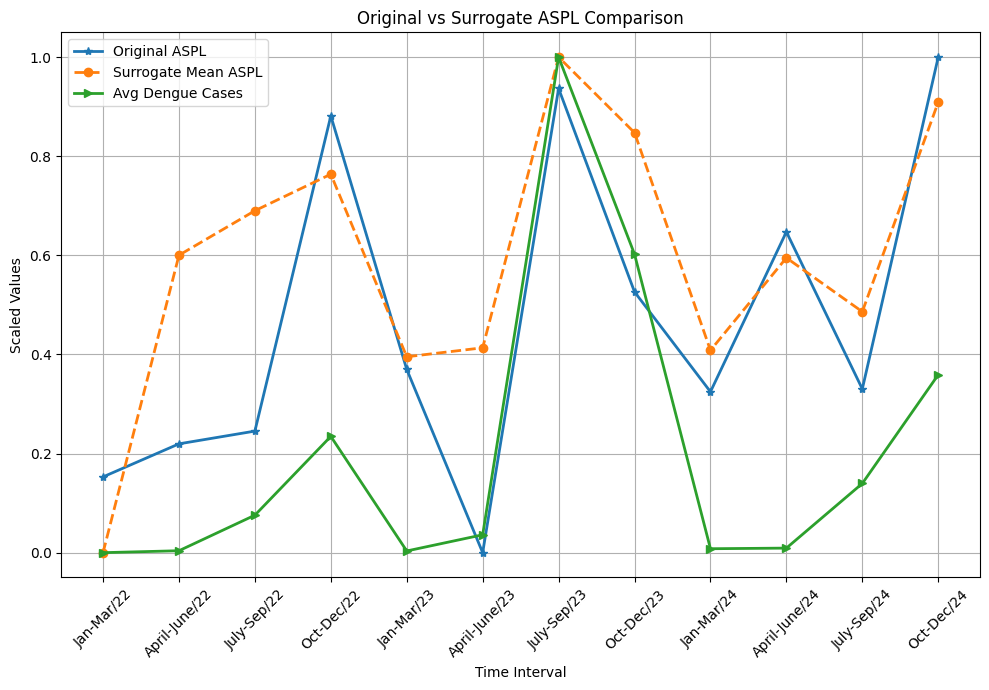

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.average_shortest_path_length(G)


# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original ASPL")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean ASPL")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate ASPL Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Z-scores: [np.float64(-1.1751288738377883), np.float64(-1.8301018164868925), np.float64(-7.122347034056795), np.float64(-0.8153503576859423), np.float64(-2.788887388353757), np.float64(-1.5140968423507675), np.float64(0.7551671480834549), np.float64(-0.7976749429577559), np.float64(-2.4366020786922866), np.float64(0.39858265774719237), np.float64(-2.8239942716174586), np.float64(-0.8420441143005449)]
1.9416647938475526


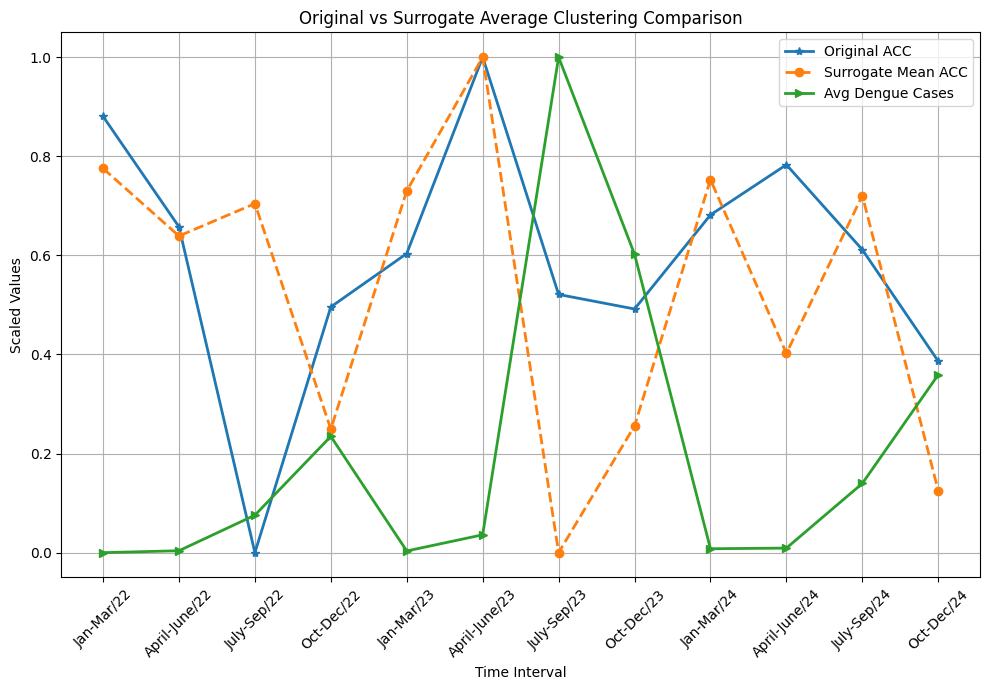

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.average_clustering(G)

# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original ACC")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean ACC")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate Average Clustering Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Z-scores: [np.float64(1.150509659397202), np.float64(6.2720979891740525), np.float64(8.710995737680289), np.float64(3.488501407649876), np.float64(-0.993080568569844), np.float64(11.205328735336472), np.float64(4.251082000731879), np.float64(13.515515416732276), np.float64(3.2342864407663448), np.float64(0.109565724038692), np.float64(2.0512417410947315), np.float64(1.161065256480959)]
4.678605889804385


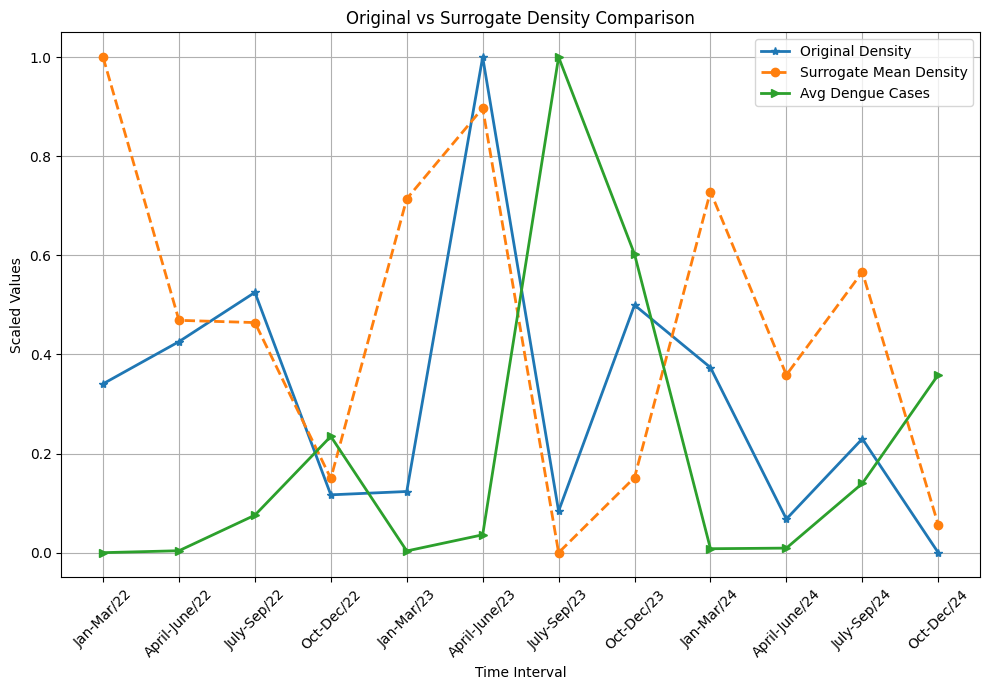

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.density(G)

# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original Density")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean Density")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate Density Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def visibility_graph(data):
    n = len(data)
    G = nx.visibility_graph(data)
    return G

[1.8444444444444446, 10.142857142857142, 162.40217391304347, 499.94565217391306, 9.144444444444444, 78.4065934065934, 2124.217391304348, 1280.141304347826, 18.736263736263737, 21.384615384615383, 298.2282608695652, 763.8478260869565]
[44, 34, 33, 23, 31, 72, 19, 30, 26, 21, 30, 20]


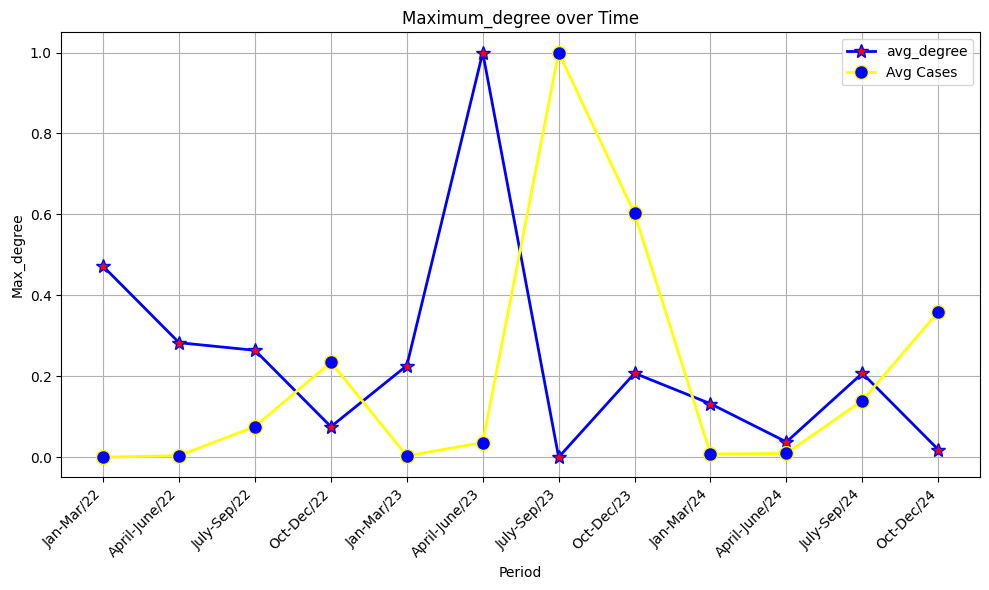

In [ ]:

def max_degree(data):
    graph = visibility_graph(data)
    #degree_sequence =dict(graph.degree())
    #mx_degree = max(degree_sequence.values())
    degree_sequence = [d for _, d in graph.degree()]
    mx_degree = max(degree_sequence)
    return mx_degree

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc1.append(max_degree(data))
  average_value1.append(avg(data))

print(average_value1)
print(avc1)
#print(monthly_data1)

x= max(average_value1)
y=max(avc1)

scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), scaled_path1, markerfacecolor='red', markersize=10, marker='*', linewidth=2, linestyle='-', color='blue', label="avg_degree")
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases")
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/23','Jan-Feb/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
plt.xlabel('Period')
plt.ylabel('Max_degree')
plt.title('Maximum_degree over Time')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

0      4.0
1     11.0
2     29.0
3      4.0
4      4.0
      ... 
85     1.0
86     0.0
87     2.0
88     4.0
89     0.0
Name: effected-people-per-day, Length: 90, dtype: float64
90      0.0
91      0.0
92      2.0
93      0.0
94      0.0
       ... 
176    32.0
177    17.0
178    47.0
179    40.0
180    33.0
Name: effected-people-per-day, Length: 91, dtype: float64
181     22.0
182     49.0
183     42.0
184     36.0
185     46.0
       ...  
268    482.0
269    460.0
270    524.0
271    506.0
272    240.0
Name: effected-people-per-day, Length: 92, dtype: float64
273    635.0
274    568.0
275    525.0
276    482.0
277    344.0
       ...  
360     62.0
361     67.0
362     65.0
363     14.0
364     47.0
Name: effected-people-per-day, Length: 92, dtype: float64
365    41.0
366    38.0
367    17.0
368    49.0
369    31.0
       ... 
450     4.0
451     6.0
452     2.0
453     6.0
454     0.0
Name: effected-people-per-day, Length: 90, dtype: float64
455      4.0
456      3.0
457      2.0


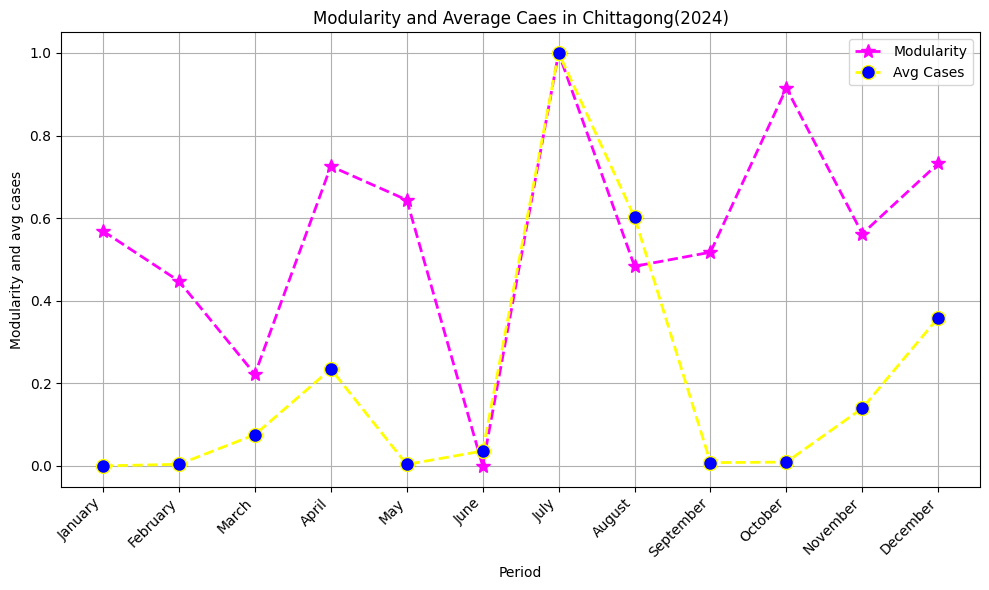

In [ ]:
def modularity(data):
    vis_graph = visibility_graph(data)
    if vis_graph.number_of_nodes() > 0:
        c =  nx.community.greedy_modularity_communities(vis_graph)
        mod = nx.community.modularity(vis_graph,c )
        return mod
    else:
        return 0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  print(data)
  avc1.append(modularity(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc1)

scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), scaled_path1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='--', color='magenta', label="Modularity")
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='--', color='yellow', label="Avg Cases")
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/23','Jan-Feb/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
#month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xlabel('Period')
plt.ylabel('Modularity and avg cases')
plt.title('Modularity and Average Caes in Chittagong(2024)')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()